In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [69]:

def plot_timeseries(df, value_columns, 
                   plot_type='line', 
                   date_range=None,
                   figsize=(15, 8),
                   title=None,
                   labels=None):
    """
    Plots time series data from a single DataFrame with a 'timestamp' column.
    Each column is plotted as a separate line with the same style but different colors.

    Args:
        df (pd.DataFrame): DataFrame with time series data (must have 'timestamp' column)
        value_columns (str or list of str): Name(s) of the value column(s) to plot
        plot_type (str): 'line', 'scatter', 'both', or 'resampled'
        date_range (tuple): (start_date, end_date) to filter the data
        figsize (tuple): Figure size (width, height)
        title (str): Custom plot title
        labels (list): Custom labels for each column (if None, uses column names)

    Returns:
        matplotlib.figure.Figure

    Examples:
        # Basic usage with multiple columns
        fig = plot_timeseries(df, ['Value1', 'Value2', 'Value3'])

        # With custom labels and plot type
        fig = plot_timeseries(df, ['Original', 'Resampled'], 
                             labels=['Raw Data', 'Hourly Avg'],
                             plot_type='line')

        # Comparing different preprocessing results
        fig = plot_timeseries(df, ['Raw', 'Hourly', 'Interpolated'],
                             labels=['Raw', 'Hourly', 'Interpolated'],
                             title='Data Preprocessing Comparison')
    """

    # Input validation
    if 'timestamp' not in df.columns:
        raise ValueError("DataFrame must have a 'timestamp' column")

    # Convert value_columns to list if it's a single string
    if isinstance(value_columns, str):
        value_columns = [value_columns]
    
    if not isinstance(value_columns, list):
        raise ValueError("value_columns must be a string or list of strings")

    if len(value_columns) == 0:
        raise ValueError("value_columns cannot be empty")

    # Check that all columns exist
    for col in value_columns:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found in DataFrame")

    # Default labels if not provided
    if labels is None:
        labels = value_columns
    elif len(labels) != len(value_columns):
        raise ValueError("Number of labels must match number of columns")

    # Color palette for different lines - use tab10 colormap for up to 10 distinct colors
    if len(value_columns) < 5:
        colors_line = plt.cm.tab10([0, 3, 6, 9])
        colors_scatter = plt.cm.tab10([1, 4, 7, 8])
    else:
        # For more than 10 columns, use a continuous colormap
        colors_line = plt.cm.viridis(np.linspace(0, 1, len(value_columns)))
        colors_scatter = colors_line  # Use same colors for scatter when many columns

    # Prepare DataFrame
    df_plot = df.copy()
    
    # Ensure timestamp column is datetime
    df_plot['timestamp'] = pd.to_datetime(df_plot['timestamp'])

    # Filter by date range
    if date_range:
        start_date, end_date = date_range
        df_plot = df_plot[(df_plot['timestamp'] >= start_date) & 
                         (df_plot['timestamp'] <= end_date)]
        print(f"Filtered to date range: {date_range}")

    print(f"Plotting {len(df_plot)} points across {len(value_columns)} columns")

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    if title is None:
        title = f"Time Series Plot ({len(df_plot):,} points)"

    # Plot each column
    for i, (col, label) in enumerate(zip(value_columns, labels)):
        # Skip if column has no valid data
        if df_plot[col].isna().all():
            print(f"Warning: Column '{col}' has no valid data")
            continue

        # Get appropriate colors
        color_line = colors_line[i]
        color_scatter = colors_scatter[i] if i < len(colors_scatter) else color_line

        # Plot types - all columns use same style but different colors
        if plot_type == 'line':
            ax.plot(df_plot['timestamp'], df_plot[col],
                    linewidth=1, alpha=1, color=color_line, label=label)

        elif plot_type == 'scatter':
            ax.scatter(df_plot['timestamp'], df_plot[col],
                       s=1, alpha=0.6, color=color_scatter, label=label)

        elif plot_type == 'both':
            ax.plot(df_plot['timestamp'], df_plot[col],
                    linewidth=0.8, alpha=0.8, color=color_line, label=f'{label} (Line)')
            ax.scatter(df_plot['timestamp'], df_plot[col],
                       s=5, alpha=0.6, color=color_scatter, label=f'{label} (Points)')

        elif plot_type == 'resampled':
            # For resampling, temporarily set timestamp as index
            df_temp = df_plot.set_index('timestamp')
            df_resampled = df_temp[col].resample('h').mean()
            ax.plot(df_resampled.index, df_resampled,
                    linewidth=1, color=color_line, label=f'{label} (Hourly Avg)')
            print(f"Column '{col}' resampled to hourly averages: {len(df_resampled)} points")

    # Labels and formatting
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Enhanced stats box for multiple columns
    stats_lines = []
    for col, label in zip(value_columns, labels):
        valid_data = df_plot[col].dropna()
        if len(valid_data) > 0:
            stats_lines.append(f"{label}:")
            stats_lines.append(f"  Min: {valid_data.min():.2f}")
            stats_lines.append(f"  Max: {valid_data.max():.2f}")
            stats_lines.append(f"  Mean: {valid_data.mean():.2f}")
            stats_lines.append(f"  Std: {valid_data.std():.2f}")
            stats_lines.append(f"  Valid: {len(valid_data)}/{len(df_plot)}")
            if col != value_columns[-1]:  # Add separator except for last
                stats_lines.append("---")

    stats_text = "\n".join(stats_lines)

    # Adjust stats box font size based on number of columns
    font_size = max(8, min(10, 10 - len(value_columns) // 3))

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.8), fontsize=font_size)

    plt.tight_layout()
    plt.show()
    # return fig

In [70]:
class LocalLinearTrendModel(sm.tsa.statespace.MLEModel):
    def __init__(self, endog):
        k_states = 2  # level and slope
        k_posdef = 2  # process noise for level and slope

        super().__init__(
            endog, k_states=k_states, k_posdef=k_posdef,
            initialization='approximate_diffuse',
            loglikelihood_burn=48*7
        )

        # Design matrix (maps state to observed y_t)
        self.ssm['design', 0, 0] = 1  

        # For transition:
        # State vector: [level, slope]
        # [level_t]   = [1  1] [level_{t-1}]
        # [slope_t]     [0  1] [slope_{t-1}]
        self.ssm['transition', 0, 0] = 1
        self.ssm['transition', 0, 1] = 1
        self.ssm['transition', 1, 1] = 1

        # Selection: which states get noise
        self.ssm['selection', 0, 0] = 1
        self.ssm['selection', 1, 1] = 1

    def update(self, params, *args, **kwargs):
        params = super().update(params, *args, **kwargs)
        # Observation noise
        self.ssm['obs_cov', 0, 0] = params[0]
        # State noise (for level and slope)
        self.ssm['state_cov', 0, 0] = params[1]
        self.ssm['state_cov', 1, 1] = params[2]

    @property
    def param_names(self):
        return ['sigma2.obs', 'sigma2.level', 'sigma2.slope']

    @property
    def start_params(self):
        return [np.std(self.endog)] * 3

    def transform_params(self, params):
        # Constrain variances to be positive
        return np.square(params)

    def untransform_params(self, params):
        return np.sqrt(params)


In [71]:
class LocalLevelWithFixedSlope(sm.tsa.statespace.MLEModel):
    def __init__(self, endog):
        k_states = 2  # level and slope
        k_posdef = 2  # process noise for level and slope

        super().__init__(
            endog, k_states=k_states, k_posdef=k_posdef,
            initialization='approximate_diffuse',
            loglikelihood_burn=48*7
        )
        self.ssm['design', 0, 0] = 1

        self.ssm['transition', 0, 0] = 1
        self.ssm['transition', 0, 1] = 1
        self.ssm['transition', 1, 1] = 1  # slope is deterministic

        self.ssm['selection', 0, 0] = 1
        self.ssm['selection', 1, 1] = 1

    def update(self, params, *args, **kwargs):
        params = super().update(params, *args, **kwargs)
        # Only estimate observation and level noise
        self.ssm['obs_cov', 0, 0] = params[0]
        self.ssm['state_cov', 0, 0] = params[1]
        # Slope noise is fixed to zero
        self.ssm['state_cov', 1, 1] = 0

    @property
    def param_names(self):
        return ['sigma2.obs', 'sigma2.level']  # Only two names

    @property
    def start_params(self):
        s = np.std(self.endog)
        return [s, s]

    def transform_params(self, params):
        return np.square(params)

    def untransform_params(self, params):
        return np.sqrt(params)


In [79]:
df = pd.read_csv('./test/data/VAR_41494_55419-odecty.csv', sep=";")[['Time of reading', 'Value', 'Diff.']]
df.rename(columns={'Diff.': 'Diff', 'Value':'hodnota', 'Time of reading':'timestamp'}, inplace=True)

#df = pd.read_csv('./test/data/artificial_water_consumption_3months.csv')
df = pd.read_csv('./filled_data_complete.csv').rename(columns={'Diff.': 'Diff', 'Value':'hodnota', 'Time of reading':'timestamp'})
df.head()

,timestamp,hodnota,Diff
0,2024-08-29 00:14:56,789.73,NaN
1,2024-08-29 00:44:56,789.73,0.0
2,2024-08-29 01:14:56,789.73,0.0
3,2024-08-29 01:44:56,789.73,0.0
4,2024-08-29 02:14:56,789.73,0.0


Plotting 17555 points across 1 columns


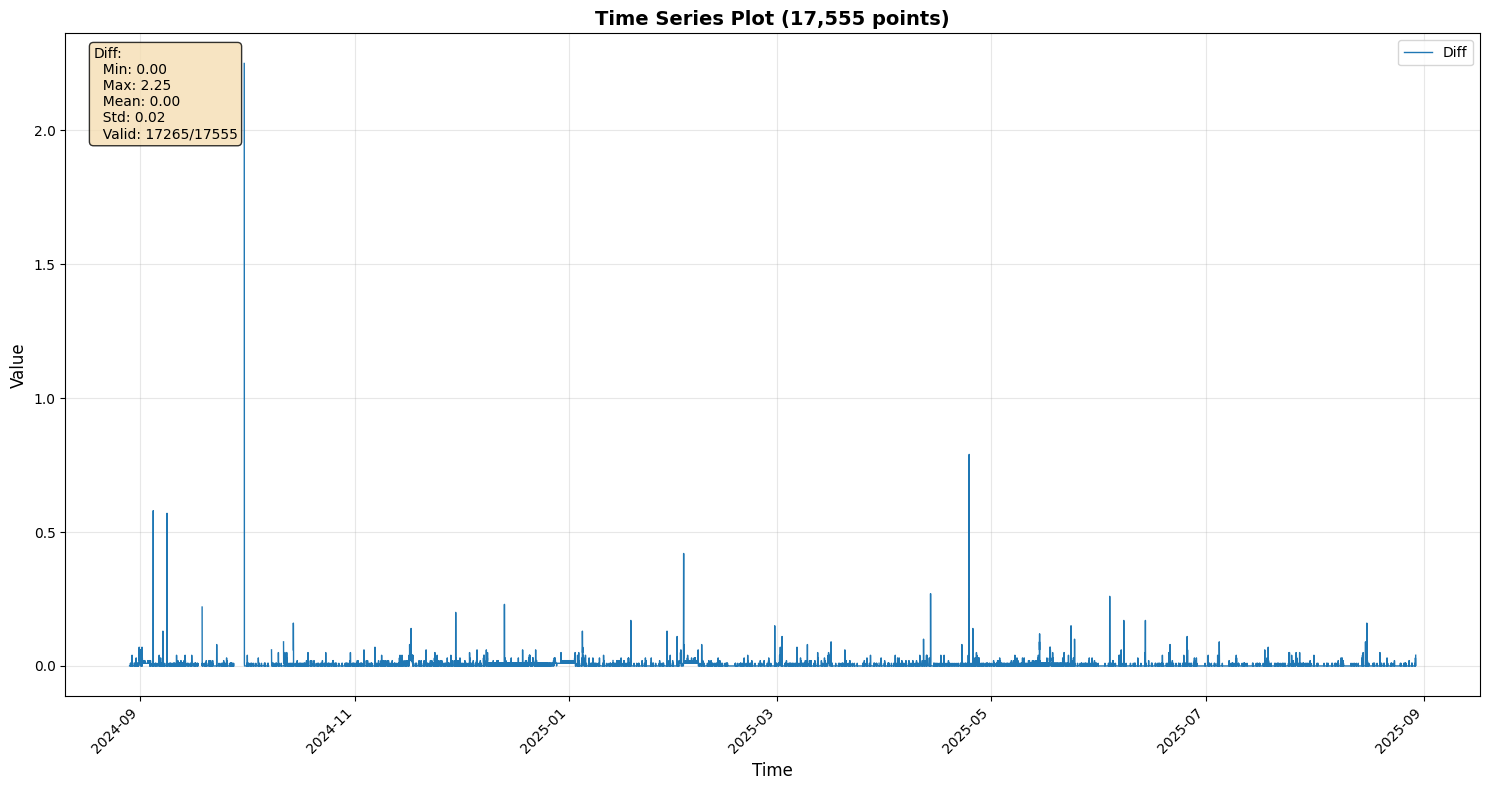

In [80]:
plot_timeseries(df, 'Diff')

In [81]:

#df = df[:2*30*48]
mod = LocalLevelWithFixedSlope(df['Diff'].values)
#mod = LocalLinearTrendModel(df['Diff'].values)
res = mod.fit()

predict = res.get_prediction()
df['Predicted Mean'] = predict.predicted_mean

print(res.mle_retvals)

{'fopt': nan, 'gopt': array([nan, nan]), 'fcalls': 66, 'warnflag': 2, 'converged': False, 'iterations': 0}


c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [75]:
print(res.summary())

c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3160: UserWarning: Early subset of data for variable 0 has too few non-missing observations to calculate test statistic.
  test_statistic, p_value = breakvar_heteroskedasticity_test(
c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3160: UserWarning: Later subset of data for variable 0 has too few non-missing observations to calculate test statistic.
  test_statistic, p_value = breakvar_heteroskedasticity_test(


                              Statespace Model Results                              
Dep. Variable:                            y   No. Observations:                17267
Model:             LocalLevelWithFixedSlope   Log Likelihood                     nan
Date:                      Mon, 24 Nov 2025   AIC                                nan
Time:                              20:41:13   BIC                                nan
Sample:                                   0   HQIC                               nan
                                    - 17267                                         
Covariance Type:                        opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
sigma2.obs          nan        nan        nan        nan         nan         nan
sigma2.level        nan        nan        nan        nan         nan         

Filtered to date range: ('2025-08-15', '2025-08-30')
Plotting 707 points across 2 columns


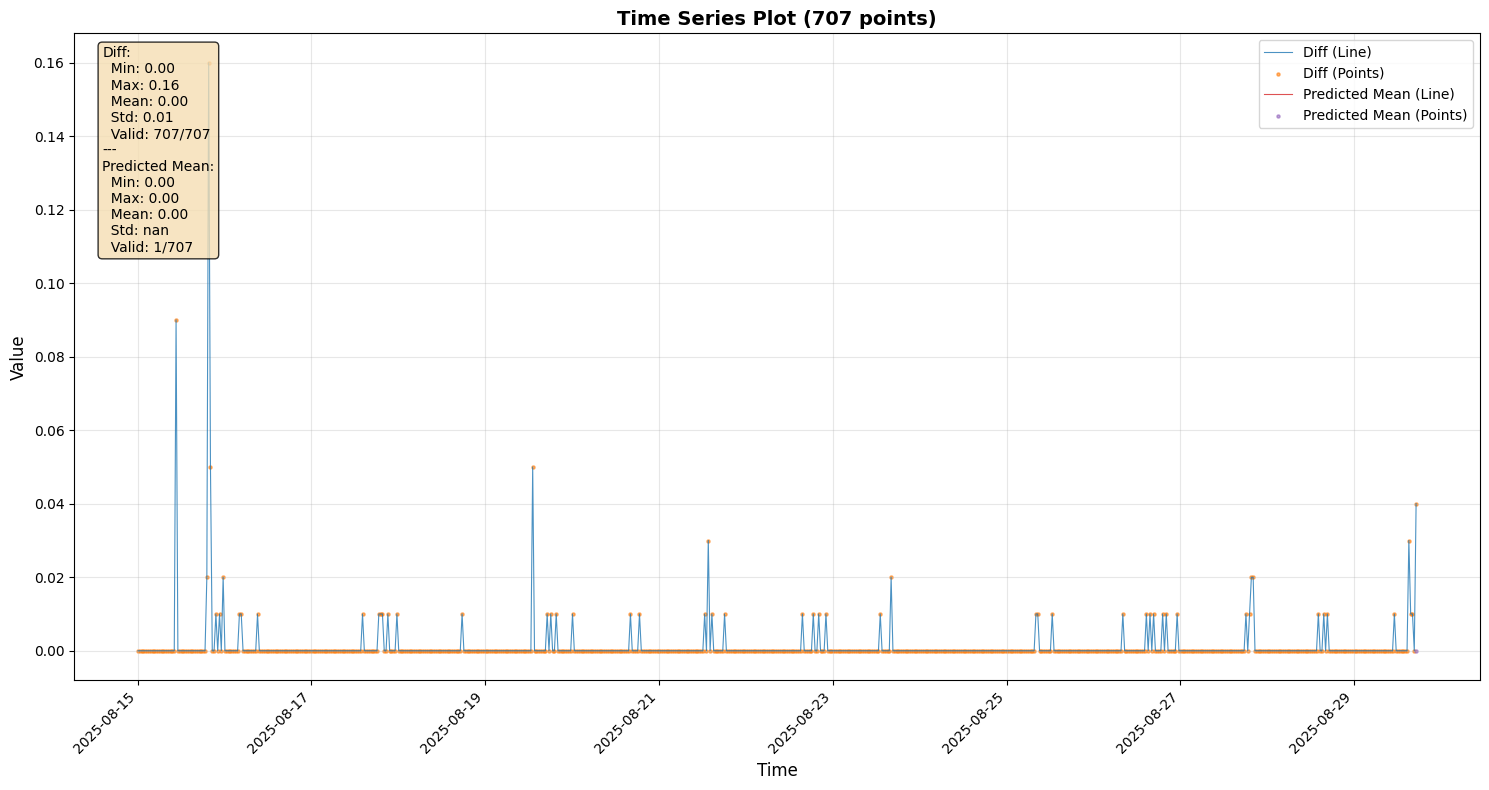

In [76]:
plot_timeseries(df, ['Diff', 'Predicted Mean'], plot_type='both', date_range=('2025-08-15', '2025-08-30'))